# Task 2: Exploratory Data Analysis

In [1]:
!pip install -U transformers datasets evaluate accelerate scikit-learn
!pip install -q nltk wordcloud spacy umap-learn
!pip install matplotlib seaborn



  Using cached transformers-5.2.0-py3-none-any.whl.metadata (32 kB)
  Using cached datasets-4.6.1-py3-none-any.whl.metadata (19 kB)
  Using cached evaluate-0.4.6-py3-none-any.whl.metadata (9.5 kB)
  Using cached accelerate-1.12.0-py3-none-any.whl.metadata (19 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached huggingface_hub-1.5.0-py3-none-any.whl.metadata (13 kB)
  Using cached numpy-2.4.2-cp312-cp312-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (2.4 kB)
  Using cached regex-2026.2.28-cp312-cp312-macosx_11_0_arm64.whl.metadata (40 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-macosx_11_0_arm64.whl.metadata (7.3 kB)
  Using cached typer_slim-0.24.0-py3-none-any.whl.metadata (4.2 kB)
  Using cached safetensors-0.7.0-cp38-abi3-macosx_11_0_arm64.whl.metadata (4.1 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached filelock-3.25.0-py3-none-any.

In [2]:
import transformers
print(transformers.__version__)

/Users/simrankaware/Documents/Imperial/Year 4/NLP/NLP_coursework_sk4122/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


5.2.0


### Load and process the PCL Dataset

In [4]:
! mkdir -p data

# Download train/dev split file (practice split)
! curl -L -o data/practice_splits.zip \https://github.com/Perez-AlmendrosC/dontpatronizeme/archive/refs/heads/master.zip

# Download test set (raw TSV)
! curl -L -o data/task4_test.tsv \https://raw.githubusercontent.com/Perez-AlmendrosC/dontpatronizeme/master/semeval-2022/TEST/task4_test.tsv

# Download dataset
! curl -L -o data/dontpatronizeme_pcl.tsv \https://raw.githubusercontent.com/CRLala/NLPLabs-2024/refs/heads/main/Dont_Patronize_Me_Trainingset/dontpatronizeme_pcl.tsv

# Unzip the dataset
!unzip data/practice_splits.zip -d data/

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  664k    0  664k    0     0  1188k      0 --:--:-- --:--:-- --:--:-- 1188k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1118k  100 1118k    0     0  4690k      0 --:--:-- --:--:-- --:--:-- 4699k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 3049k  100 3049k    0     0  10.2M      0 --:--:-- --:--:-- --:--:-- 10.2M
Archive:  data/practice_splits.zip
b9e74509e37de0b989e339c59e95362dc06b0184
   creating: data//dontpatronizeme-master
  inflating: data//dontpatronizeme-master/Data_Statement_DontPatronizeMe.pdf  
  inflating: 

In [5]:
import pandas as pd

# Load the full PCL dataset
full_df = pd.read_csv(
    "data/dontpatronizeme_pcl.tsv",
    sep="\t",
    skiprows=3, # disclaimer is lines 1–3, data starts at line 4
    header=None
)

# Assign column names
full_df.columns = ["par_id", "art_id", "keyword", "country_code", "text", "label"]

# Convert graded label (0–4) -> binary (0/1) using {0,1}=NoPCL and {2,3,4}=PCL
full_df["label"] = full_df["label"].astype(int)
full_df["label_bin"] = (full_df["label"] >= 2).astype(int)

# Load split IDs
train_ids = pd.read_csv("data/dontpatronizeme-master/semeval-2022/practice splits/train_semeval_parids-labels.csv")
dev_ids   = pd.read_csv("data/dontpatronizeme-master/semeval-2022/practice splits/dev_semeval_parids-labels.csv")

# Ensure types match
full_df["par_id"] = full_df["par_id"].astype(int)
train_ids["par_id"] = train_ids["par_id"].astype(int)
dev_ids["par_id"] = dev_ids["par_id"].astype(int)

# Merge to get actual train/dev dataframes
train_df = full_df.merge(train_ids[["par_id"]], on="par_id", how="inner")
dev_df   = full_df.merge(dev_ids[["par_id"]], on="par_id", how="inner")

print("Train shape:", train_df.shape)
print("Dev shape:", dev_df.shape)
print("\nTrain label distribution:\n", train_df["label_bin"].value_counts())

Train shape: (8375, 7)
Dev shape: (2094, 7)

Train label distribution:
 label_bin
0    7581
1     794
Name: count, dtype: int64


### Technique 1: Basic Statistical Profiling

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re

In [7]:
# Fill all NAs with empty strings for easier processing
train_df["text"] = train_df["text"].fillna("")
dev_df["text"] = dev_df["text"].fillna("")

#### 1. Token Count (Sentence Length Statistics) ####

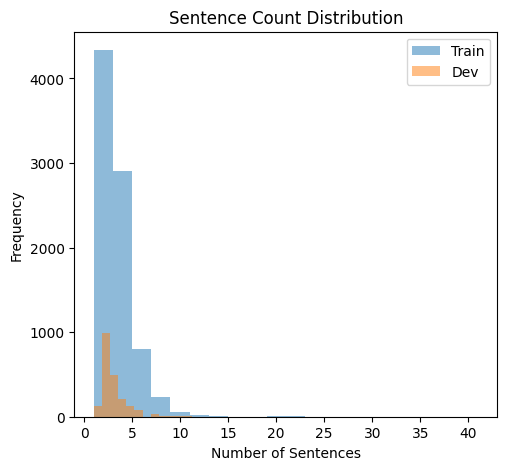

In [8]:
# Simple tokeniser (split on full stop to determine sentence count, split on whitespace to determine word count)
def count_tokens(text):
    sentences = text.split('.')
    word_count = sum(len(sentence.strip().split()) for sentence in sentences if sentence.strip())
    return len(sentences), word_count

# Apply token counting to train and dev dataframes
train_df["sentence_count"], train_df["word_count"] = zip(*train_df["text"].apply(count_tokens))
dev_df["sentence_count"], dev_df["word_count"] = zip(*dev_df["text"].apply(count_tokens))

# Plot sentence count distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(train_df["sentence_count"], bins=20, alpha=0.5, label="Train")
plt.hist(dev_df["sentence_count"], bins=20, alpha=0.5, label="Dev")
plt.title("Sentence Count Distribution")
plt.xlabel("Number of Sentences")
plt.ylabel("Frequency")
plt.legend()    

#### 2. Vocabulary Size (Unique Word Proportion)


In [9]:
# Tokenize text into words
def simple_tokenize(text: str):
  return re.findall(r"[a-zA-Z]+(?:'[a-zA-Z]+)?", str(text).lower())

all_tokens = []
for t in train_df["text"].tolist() + dev_df["text"].tolist():
    all_tokens.extend(simple_tokenize(t))

vocab = set(all_tokens)
counts = Counter(all_tokens)
rare_1 = sum(1 for word in vocab if counts[word] == 1)
rare_5 = sum(1 for word in vocab if counts[word] <= 5)

vocab_table = pd.DataFrame([{
   "total_tokens": len(all_tokens),
   "vocab_size": len(vocab),
   "rare_1_count": rare_1,
   "rare_1_pct": rare_1 / len(vocab) * 100,
   "rare_5_count": rare_5,
   "rare_5_pct": rare_5 / len(vocab) * 100,
}])

print("\n=== Vocabulary Statistics ===")
print(vocab_table.to_string(index=False))


=== Vocabulary Statistics ===
 total_tokens  vocab_size  rare_1_count  rare_1_pct  rare_5_count  rare_5_pct
       452194       29091         14045   48.279537         22808   78.402255


#### 3. Class Distribution ####


=== TRAIN: Class Distribution ===


,count,proportion
label_bin,,
0,7581,0.9052
1,794,0.0948



=== DEV: Class Distribution ===


,count,proportion
label_bin,,
0,1895,0.905
1,199,0.095


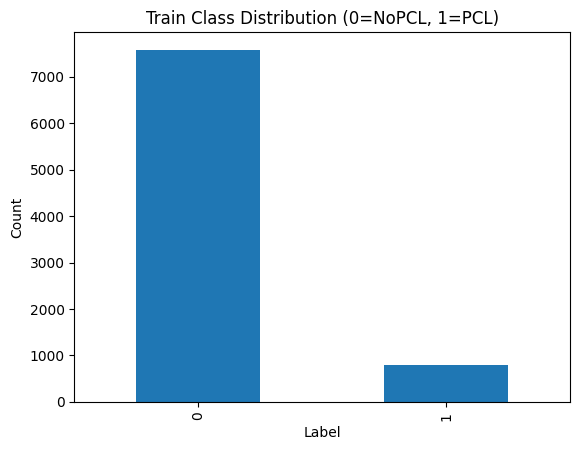

In [10]:
def class_profile(df, label_col="label_bin", name="TRAIN"):
    counts = df[label_col].value_counts().sort_index()
    props = (counts / counts.sum()).round(4)
    out = pd.DataFrame({"count": counts, "proportion": props})
    print(f"\n=== {name}: Class Distribution ===")
    display(out)
    return out

train_class_table = class_profile(train_df, name="TRAIN")
dev_class_table   = class_profile(dev_df, name="DEV")

plt.figure()
train_df["label_bin"].value_counts().sort_index().plot(kind="bar")
plt.title("Train Class Distribution (0=NoPCL, 1=PCL)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

### Technique 2: Lexical Analysis


#### 1. N-gram Analysis ####

In [11]:
from itertools import islice

import nltk
import seaborn as sns
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

nltk.download("stopwords", quiet=True)

# Build a combined corpus for global lexical analyses
combined_df = pd.concat([
    train_df.assign(split="train"),
    dev_df.assign(split="dev")
], ignore_index=True)
combined_df["text"] = combined_df["text"].fillna("").astype(str)

# Reuse tokenizer from Technique 1
def tokenize_for_eda(text: str):
    return simple_tokenize(text)

EN_STOPWORDS = set(stopwords.words("english"))


Top 20 Bigrams


,ngram,count
0,of the,2711
1,in the,2460
2,to the,1315
3,in need,1025
4,poor families,921
5,for the,873
6,on the,811
7,to be,740
8,and the,734
9,at the,653


Top 20 Trigrams


,ngram,count
0,in need of,594
1,from poor families,230
2,one of the,190
3,those in need,162
4,as well as,153
5,the united states,145
6,the number of,135
7,the most vulnerable,122
8,in the country,114
9,are in need,111


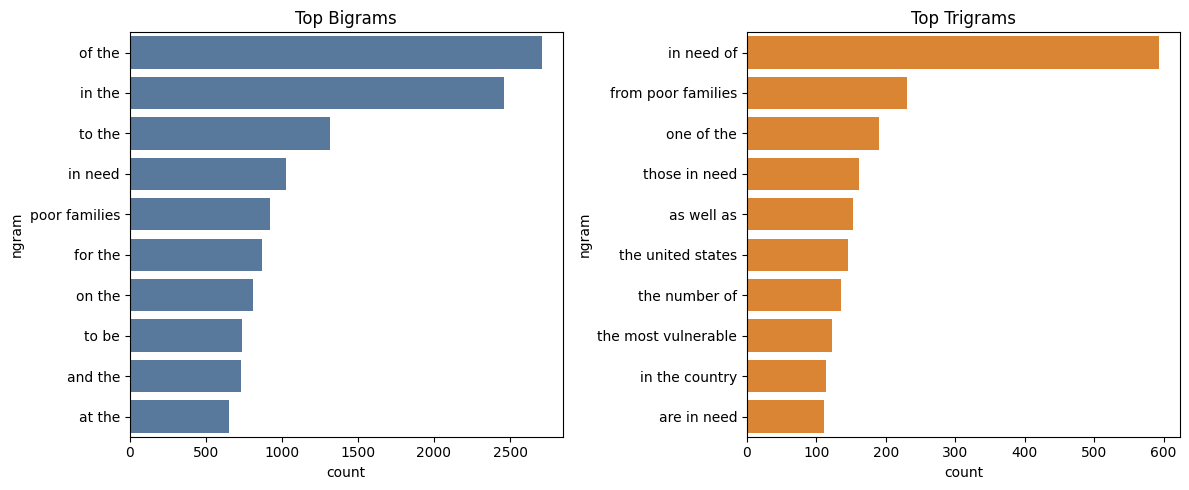

In [12]:
# 2.1 N-gram Analysis (bigrams + trigrams)
def get_top_ngrams(texts, ngram_range=(2, 2), top_k=20):
    vec = CountVectorizer(
        tokenizer=tokenize_for_eda,
        preprocessor=None,
        lowercase=True,
        token_pattern=None,
        ngram_range=ngram_range,
        min_df=2
    )
    X = vec.fit_transform(texts)
    freqs = np.asarray(X.sum(axis=0)).ravel()
    vocab = np.array(vec.get_feature_names_out())
    order = np.argsort(freqs)[::-1][:top_k]
    return pd.DataFrame({"ngram": vocab[order], "count": freqs[order]})

bigram_top = get_top_ngrams(combined_df["text"], ngram_range=(2, 2), top_k=20)
trigram_top = get_top_ngrams(combined_df["text"], ngram_range=(3, 3), top_k=20)

print("Top 20 Bigrams")
display(bigram_top)
print("Top 20 Trigrams")
display(trigram_top)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(data=bigram_top.head(10), x="count", y="ngram", color="#4C78A8")
plt.title("Top Bigrams")

plt.subplot(1, 2, 2)
sns.barplot(data=trigram_top.head(10), x="count", y="ngram", color="#F58518")
plt.title("Top Trigrams")

plt.tight_layout()
plt.show()


#### 2. Stop Word Density ####

Stopword density by split


,mean,median,std,min,max
split,,,,,
dev,0.4231,0.4262,0.0894,0.0,0.6923
train,0.4253,0.4286,0.0881,0.0,0.7500


Stopword density by class (0=NoPCL, 1=PCL)


,mean,median,std,min,max
label_bin,,,,,
0,0.4220,0.4242,0.0884,0.0,0.7500
1,0.4522,0.4545,0.0832,0.1,0.6667


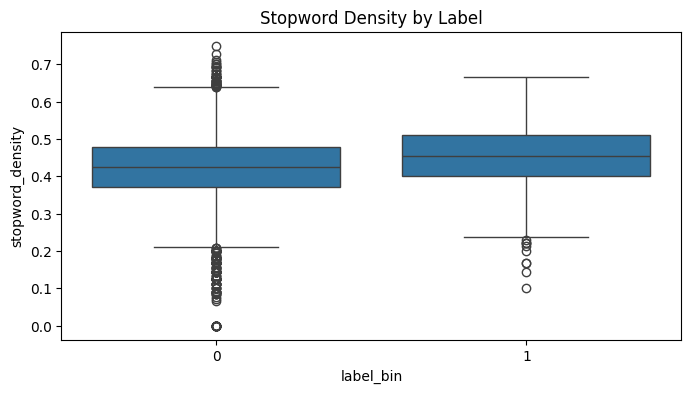

In [13]:
def stopword_density(text: str, stopword_set=EN_STOPWORDS):
    toks = tokenize_for_eda(text)
    if not toks:
        return 0.0
    sw = sum(1 for t in toks if t in stopword_set)
    return sw / len(toks)

combined_df["stopword_density"] = combined_df["text"].apply(stopword_density)

summary_split = combined_df.groupby("split")["stopword_density"].agg(["mean", "median", "std", "min", "max"]).round(4)
summary_label = combined_df.groupby("label_bin")["stopword_density"].agg(["mean", "median", "std", "min", "max"]).round(4)

print("Stopword density by split")
display(summary_split)
print("Stopword density by class (0=NoPCL, 1=PCL)")
display(summary_label)

plt.figure(figsize=(8, 4))
sns.boxplot(data=combined_df, x="label_bin", y="stopword_density")
plt.title("Stopword Density by Label")
plt.xlabel("label_bin")
plt.show()


#### 3. Word Clouds and Frequency ####

Top 25 tokens (raw)


,token,count
0,the,25891
1,to,14155
2,of,13936
3,and,12850
4,in,11052
5,a,9221
6,for,4895
7,that,4837
8,is,4513
9,s,3448


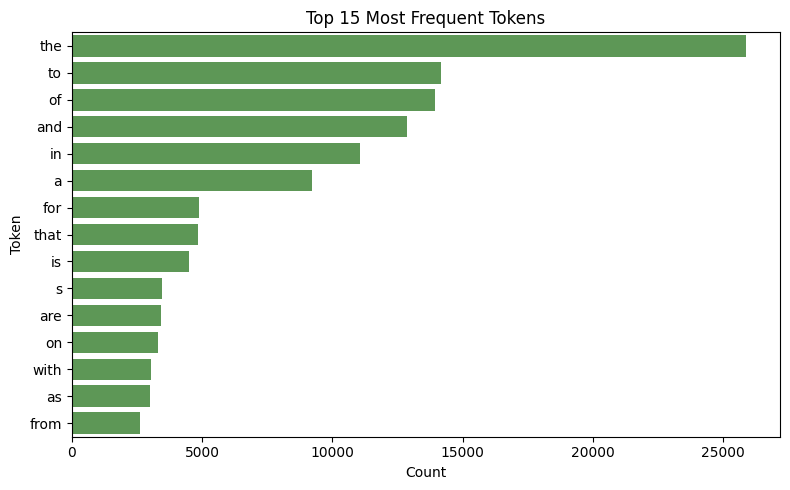

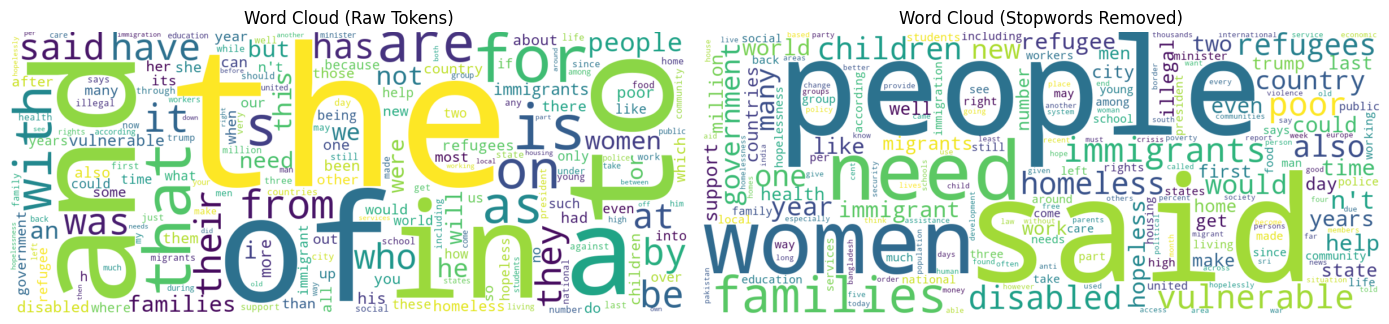

In [14]:
all_tokens_eda = []
for txt in combined_df["text"]:
    all_tokens_eda.extend(tokenize_for_eda(txt))

freq_series = pd.Series(all_tokens_eda).value_counts()
print("Top 25 tokens (raw)")
display(freq_series.head(25).rename_axis("token").reset_index(name="count"))

plt.figure(figsize=(8, 5))
sns.barplot(
    x=freq_series.head(15).values,
    y=freq_series.head(15).index,
    color="#54A24B"
)
plt.title("Top 15 Most Frequent Tokens")
plt.xlabel("Count")
plt.ylabel("Token")
plt.tight_layout()
plt.show()

# Optional: remove stopwords for a cleaner semantic cloud
content_tokens = [t for t in all_tokens_eda if t not in EN_STOPWORDS and len(t) > 2]
content_freq = pd.Series(content_tokens).value_counts()

wc_raw = WordCloud(width=1200, height=500, background_color="white").generate_from_frequencies(freq_series.head(500).to_dict())
wc_content = WordCloud(width=1200, height=500, background_color="white").generate_from_frequencies(content_freq.head(500).to_dict())

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(wc_raw, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud (Raw Tokens)")

plt.subplot(1, 2, 2)
plt.imshow(wc_content, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud (Stopwords Removed)")

plt.tight_layout()
plt.show()


### Technique 3: Semantic & Syntactic Exploration


In [15]:
# Load spaCy model for POS + NER
import spacy

try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    !python -m spacy download en_core_web_sm
    nlp = spacy.load("en_core_web_sm")

# Keep processing tractable for notebook runtime
sample_size = min(1500, len(combined_df))
sample_df = combined_df.sample(sample_size, random_state=42).reset_index(drop=True)

docs = list(nlp.pipe(sample_df["text"].tolist(), batch_size=64, disable=[]))
print(f"Processed {len(docs)} documents for POS/NER analysis")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 30.2 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
Processed 1500 documents for POS/NER analysis


#### 1. Part-of-Speech (POS) Tagging Distribution

,pos,count,pct
2,NOUN,15038,23.13
0,ADP,8719,13.41
3,VERB,8007,12.31
1,DET,6082,9.35
5,ADJ,5830,8.97
4,PROPN,5526,8.50
7,PRON,4022,6.19
8,AUX,3654,5.62
6,ADV,2545,3.91
10,CCONJ,2243,3.45


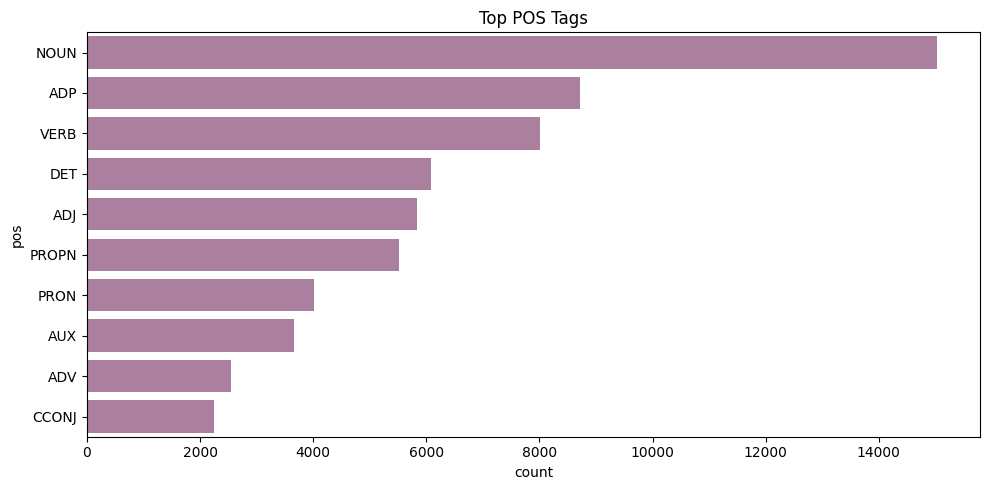

In [16]:
from collections import Counter

pos_counter = Counter()
for doc in docs:
    pos_counter.update([tok.pos_ for tok in doc if tok.is_alpha])

pos_df = pd.DataFrame(pos_counter.items(), columns=["pos", "count"]).sort_values("count", ascending=False)
pos_df["pct"] = (pos_df["count"] / pos_df["count"].sum() * 100).round(2)

display(pos_df.head(15))

plt.figure(figsize=(10, 5))
sns.barplot(data=pos_df.head(10), x="count", y="pos", color="#B279A2")
plt.title("Top POS Tags")
plt.tight_layout()
plt.show()


#### 2. Named Entity Recognition (NER)

,entity_type,count
3,GPE,992
4,ORG,953
1,PERSON,764
0,DATE,755
5,CARDINAL,703
2,NORP,455
11,LOC,119
6,ORDINAL,88
16,MONEY,50
17,TIME,48


Entity examples (up to 5 per label)


,entity_type,count,examples
3,GPE,992,"AI, Aadhar, Abbott, Accra, Addis Ababa"
4,ORG,953,"3D, > Leave a Reply, ABC Melbourne, ABG, ADR"
1,PERSON,764,"-AFP, 100s, AIIB, Aaron, Abdul Sattar Edhi"
0,DATE,755,"' 80s, ' 90s, 0842001-8-0017225, 10, 10-year"
5,CARDINAL,703,"1, 1,000, 1,014, 1,150, 1,288"
2,NORP,455,"Afghan, Afghani, Afghans, African, African Ame..."
11,LOC,119,"Africa, Alain Homsy, Algeciras, Antarctic, Ant..."
6,ORDINAL,88,"117th, 18th, 3rd, 62nd, 6th"
16,MONEY,50,"$1 million, $3.2 billion, $47 million, 100,000..."
17,TIME,48,"10:01, 11am to 9pm, 1pm, 231 night, 24 to 48 h..."


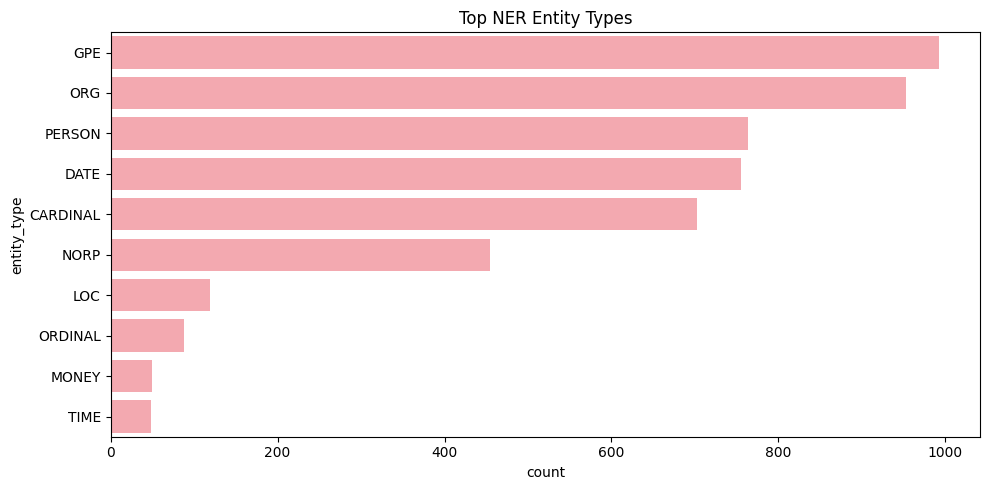

In [17]:
entity_counter = Counter()
entity_examples = {}

for doc in docs:
    for ent in doc.ents:
        entity_counter[ent.label_] += 1
        entity_examples.setdefault(ent.label_, set()).add(ent.text)

ner_df = pd.DataFrame(entity_counter.items(), columns=["entity_type", "count"]).sort_values("count", ascending=False)

display(ner_df)

example_rows = []
for label, values in entity_examples.items():
    example_rows.append({
        "entity_type": label,
        "examples": ", ".join(list(islice(sorted(values), 5)))
    })
example_df = pd.DataFrame(example_rows).merge(ner_df, on="entity_type", how="left").sort_values("count", ascending=False)

print("Entity examples (up to 5 per label)")
display(example_df[["entity_type", "count", "examples"]])

plt.figure(figsize=(10, 5))
sns.barplot(data=ner_df.head(10), x="count", y="entity_type", color="#FF9DA6")
plt.title("Top NER Entity Types")
plt.tight_layout()
plt.show()


#### 3. Embedding Visualisation (t-SNE + optional UMAP)

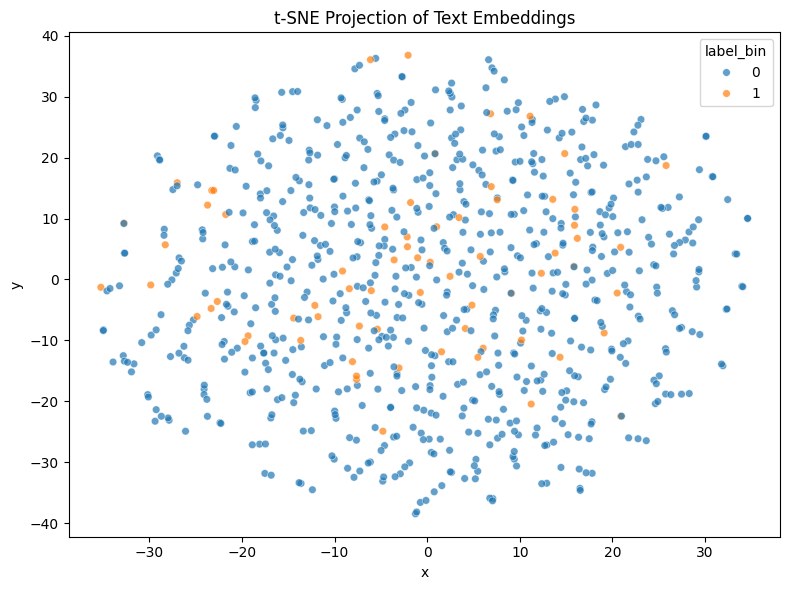

/Users/simrankaware/Documents/Imperial/Year 4/NLP/NLP_coursework_sk4122/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


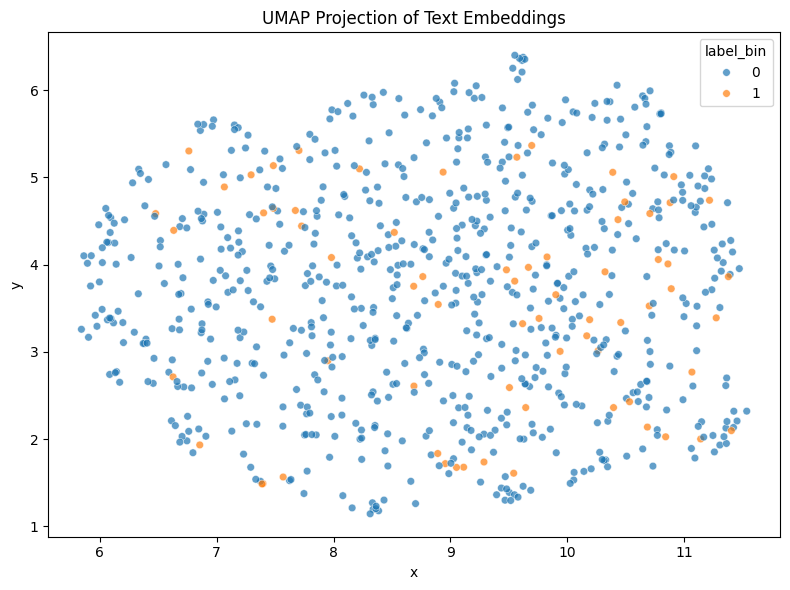

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE

# Sample texts for projection
viz_df = combined_df.sample(min(800, len(combined_df)), random_state=7).copy()

vectorizer = TfidfVectorizer(max_features=1000, stop_words="english")
X = vectorizer.fit_transform(viz_df["text"]).toarray()

# t-SNE projection
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init="pca", learning_rate="auto")
X_tsne = tsne.fit_transform(X)

plot_df = pd.DataFrame({
    "x": X_tsne[:, 0],
    "y": X_tsne[:, 1],
    "label_bin": viz_df["label_bin"].values.astype(str)
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x="x", y="y", hue="label_bin", alpha=0.7, s=30)
plt.title("t-SNE Projection of Text Embeddings")
plt.legend(title="label_bin")
plt.tight_layout()
plt.show()

# Optional UMAP projection (if available)
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=42)
    X_umap = reducer.fit_transform(X)
    umap_df = pd.DataFrame({
        "x": X_umap[:, 0],
        "y": X_umap[:, 1],
        "label_bin": viz_df["label_bin"].values.astype(str)
    })

    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=umap_df, x="x", y="y", hue="label_bin", alpha=0.7, s=30)
    plt.title("UMAP Projection of Text Embeddings")
    plt.legend(title="label_bin")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"UMAP skipped: {e}")


### Technique 4: Identifying Noise and Artifacts


#### 1. Duplicate Detection

In [19]:
def normalize_text_for_dup(s: str):
    s = str(s).lower().strip()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[^a-z0-9\s]", "", s)
    return s

combined_df["norm_text"] = combined_df["text"].apply(normalize_text_for_dup)

exact_dup_mask = combined_df.duplicated(subset=["text"], keep=False)
norm_dup_mask = combined_df.duplicated(subset=["norm_text"], keep=False)

print("Exact duplicate rows:", int(exact_dup_mask.sum()))
print("Normalized duplicate rows:", int(norm_dup_mask.sum()))

exact_dups = combined_df.loc[exact_dup_mask, ["par_id", "split", "label_bin", "text"]].head(10)
norm_dups = combined_df.loc[norm_dup_mask, ["par_id", "split", "label_bin", "text"]].head(10)

print("Sample exact duplicates")
display(exact_dups)
print("Sample normalized duplicates")
display(norm_dups)


Exact duplicate rows: 0
Normalized duplicate rows: 0
Sample exact duplicates


,par_id,split,label_bin,text


Sample normalized duplicates


,par_id,split,label_bin,text


#### 2. Special Characters/ HTML Artifcats

In [25]:
artifact_patterns = {
    "html_entity": r"&(?:amp|lt|gt|quot|nbsp|#\d+);",
    "html_tag": r"<[^>]+>",
    "escaped_newline": r"\\n",
    "escaped_tab": r"\\t",
    "url": r"https?://\S+",
    "non_ascii": r"[^\x00-\x7F]",
    "repeated_punct": r"([!?.,])\1{2,}"
}

artifact_rows = []
for name, pattern in artifact_patterns.items():
    # use Python regex engine to support backreferences (\1) – pyarrow's
    # engine throws ArrowInvalid otherwise
    mask = combined_df["text"].apply(lambda x: bool(re.search(pattern, str(x))))
    artifact_rows.append({"artifact": name, "count": int(mask.sum()), "pct": round(mask.mean() * 100, 2)})

artifact_df = pd.DataFrame(artifact_rows).sort_values("count", ascending=False)
display(artifact_df)

# Show a few examples with detected artifacts
def first_match(pattern, text):
    m = re.search(pattern, text)
    return m.group(0) if m else None

example_artifacts = []
for _, row in artifact_df.head(4).iterrows():
    name = row["artifact"]
    pattern = artifact_patterns[name]
    subset = combined_df[combined_df["text"].apply(lambda x: bool(re.search(pattern, str(x))))].head(3)
    for _, r in subset.iterrows():
        example_artifacts.append({
            "artifact": name,
            "par_id": r["par_id"],
            "match": first_match(pattern, r["text"]),
            "text_snippet": r["text"][:180]
        })

display(pd.DataFrame(example_artifacts))


,artifact,count,pct
1,html_tag,401,3.83
6,repeated_punct,271,2.59
0,html_entity,78,0.75
2,escaped_newline,0,0.00
3,escaped_tab,0,0.00
4,url,0,0.00
5,non_ascii,0,0.00


,artifact,par_id,match,text_snippet
0,html_tag,16,<h>,"Apart from Pakistan and hosts England , Bangla..."
1,html_tag,38,<h>,Rizvi : There will be no joy this Eid <h> ' Th...
2,html_tag,55,<h>,"Over the past 15 years , the show has handed o..."
3,repeated_punct,134,...,SoCO 's Ng says that the government ceases to ...
4,repeated_punct,177,...,""" The United States is a nation of immigrants ..."
5,repeated_punct,242,...,What Dublin needs to do to make itself more at...
6,html_entity,56,&gt;,"People who are homeless , those who were once ..."
7,html_entity,99,&amp;,The departures from London will barely put a d...
8,html_entity,249,&amp;,Another collective sale leads the region 's re...


#### 3. Outlier Detection (very short / very long sequences)

Outlier thresholds -> short <= 1, long >= 92
Short outliers: 2
Long outliers: 512


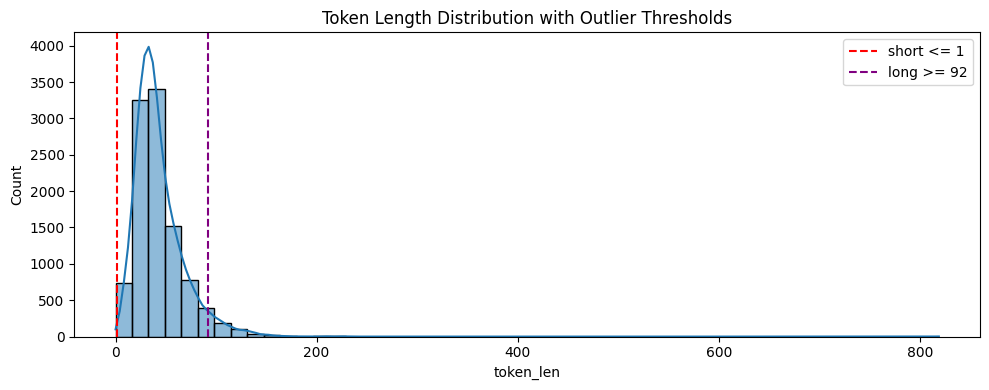

Examples of short sequences


,par_id,label_bin,token_len,text
1620,1657,0,1,refugees
8776,8640,0,0,


Examples of long sequences


,par_id,label_bin,token_len,text
0,1,0,115,"We 're living in times of absolute insanity , ..."
26,27,0,142,""" I think that , you know , led to me being de..."
43,44,0,113,Comrade David Kerigbo Ugondo was born to the f...
50,51,0,113,Number 3 : We 're not all weird hippies living...
70,71,0,94,But how often should we shave if we no longer ...
77,78,0,139,But Prabha was one of the few fortunate women ...
94,95,0,106,Careful here . The way society has changed has...
95,96,0,107,In the wake of the sexual-assault allegations ...
120,122,0,102,Kate and Julian are one of Melbourne 's most p...
127,129,0,121,"The bill had been proposed in May 2015 , but f..."


In [26]:
combined_df["token_len"] = combined_df["text"].apply(lambda x: len(tokenize_for_eda(x)))

q1 = combined_df["token_len"].quantile(0.25)
q3 = combined_df["token_len"].quantile(0.75)
iqr = q3 - q1
low_thr = max(1, int(q1 - 1.5 * iqr))
high_thr = int(q3 + 1.5 * iqr)

short_mask = combined_df["token_len"] <= low_thr
long_mask = combined_df["token_len"] >= high_thr

print(f"Outlier thresholds -> short <= {low_thr}, long >= {high_thr}")
print("Short outliers:", int(short_mask.sum()))
print("Long outliers:", int(long_mask.sum()))

plt.figure(figsize=(10, 4))
sns.histplot(combined_df["token_len"], bins=50, kde=True)
plt.axvline(low_thr, color="red", linestyle="--", label=f"short <= {low_thr}")
plt.axvline(high_thr, color="purple", linestyle="--", label=f"long >= {high_thr}")
plt.title("Token Length Distribution with Outlier Thresholds")
plt.xlabel("token_len")
plt.legend()
plt.tight_layout()
plt.show()

print("Examples of short sequences")
display(combined_df.loc[short_mask, ["par_id", "label_bin", "token_len", "text"]].head(10))

print("Examples of long sequences")
display(combined_df.loc[long_mask, ["par_id", "label_bin", "token_len", "text"]].head(10))
